In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("../data/clean_data/BankChurners_clean.csv")

# I decided to drop the Naive Bayes columns as I thought they were the result
# of prior analysis rather than columns of the original dataset.
df = df.drop(columns=['Naive_Bayes_1', 'Naive_Bayes_2'])


KeyError: "['Naive_Bayes_1', 'Naive_Bayes_2'] not found in axis"

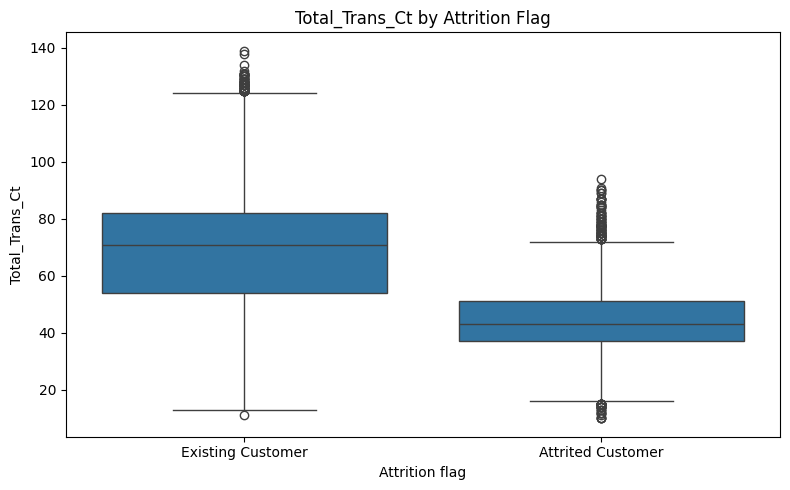

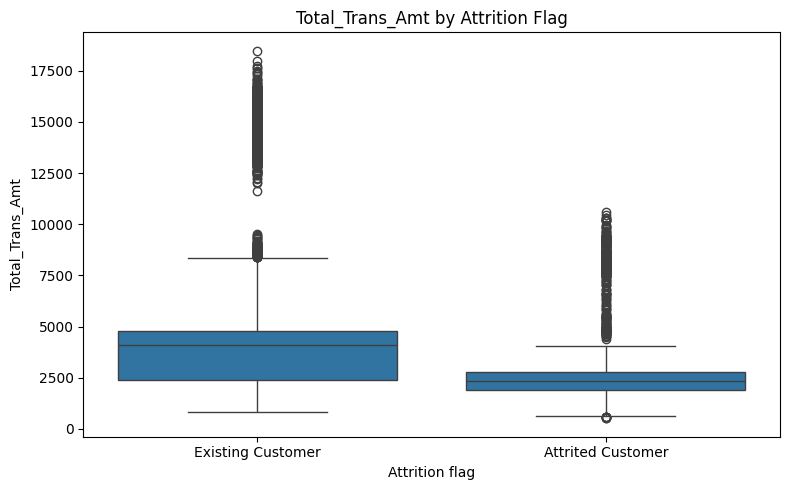

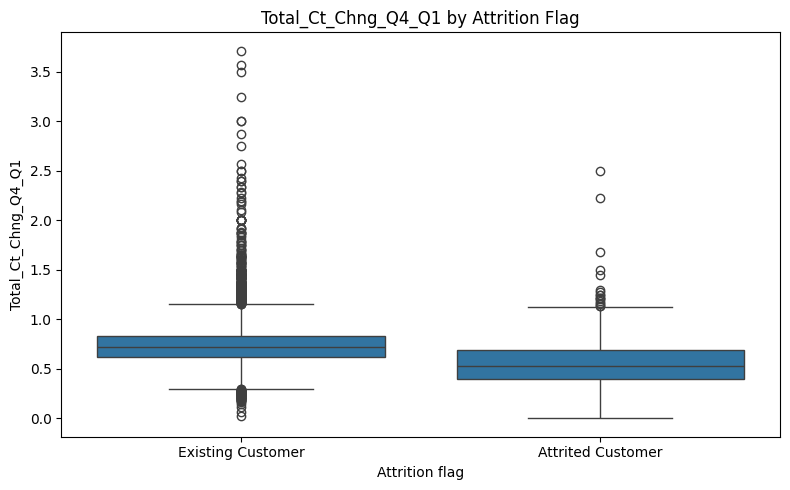

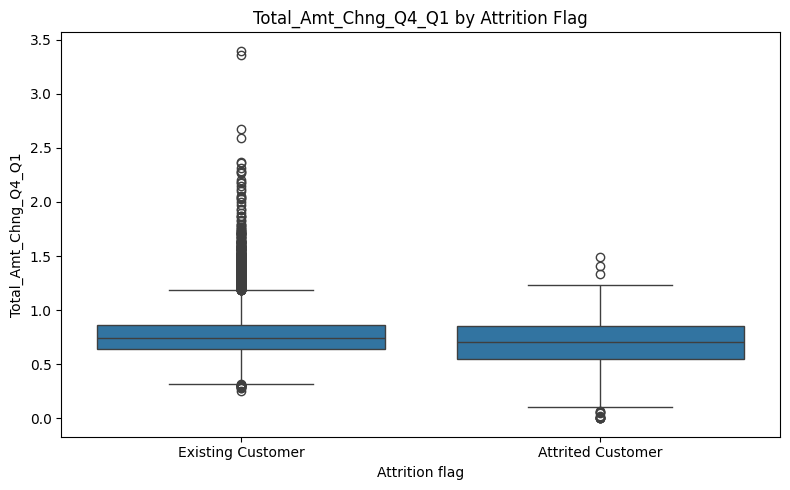

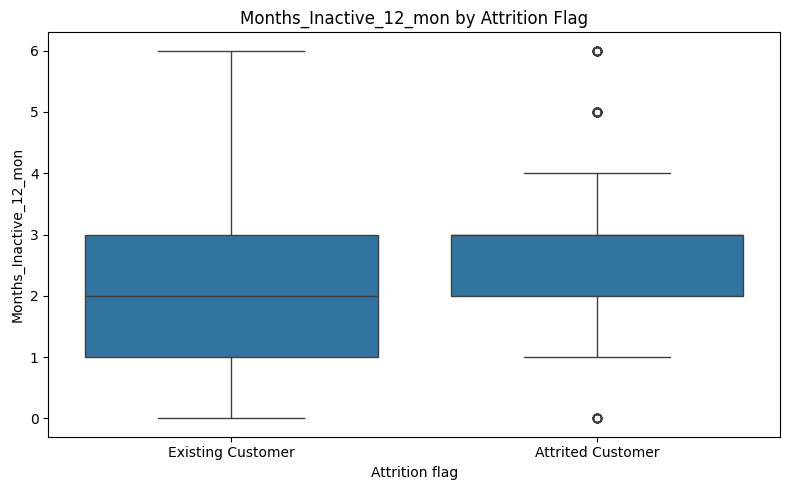

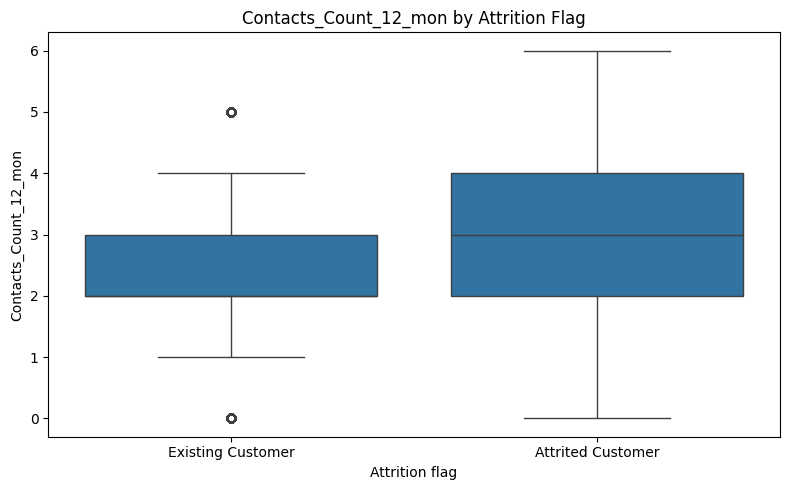

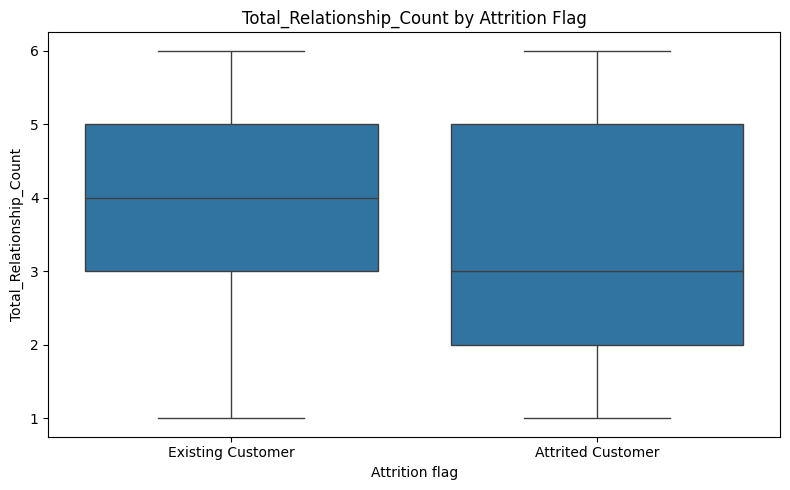

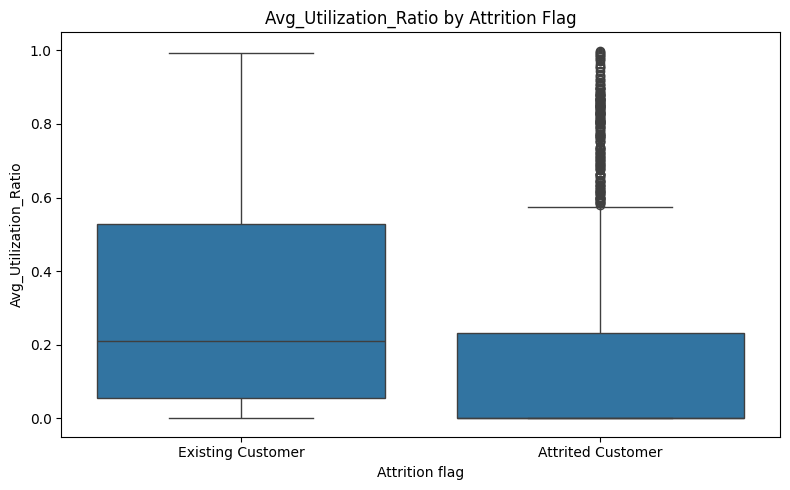

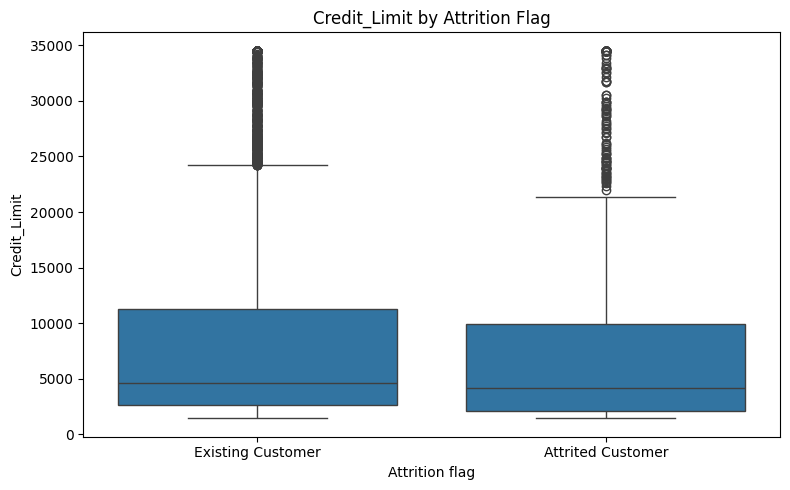

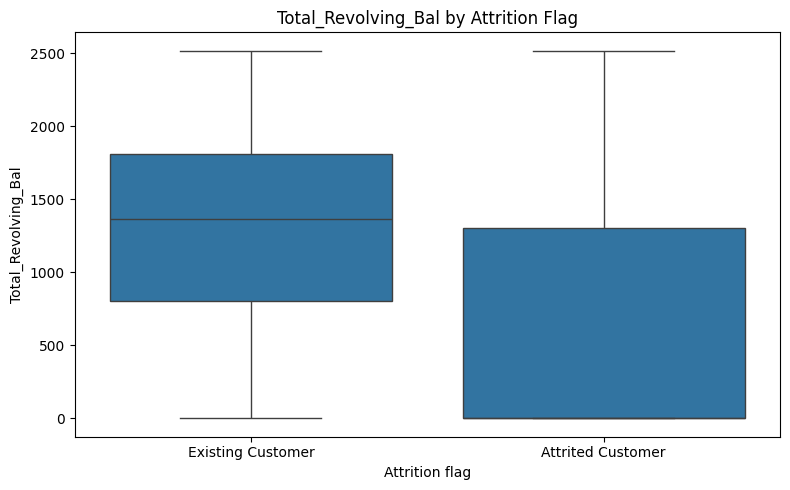

In [10]:
variables = [
    'Total_Trans_Ct',
    'Total_Trans_Amt',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Amt_Chng_Q4_Q1',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Total_Relationship_Count',
    'Avg_Utilization_Ratio',
    'Credit_Limit',
    'Total_Revolving_Bal'
]

for variable in variables:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x='Attrition_Flag',
        y=variable
    )
    
    plt.title(f'{variable} by Attrition Flag')
    plt.xlabel('Attrition flag')
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()

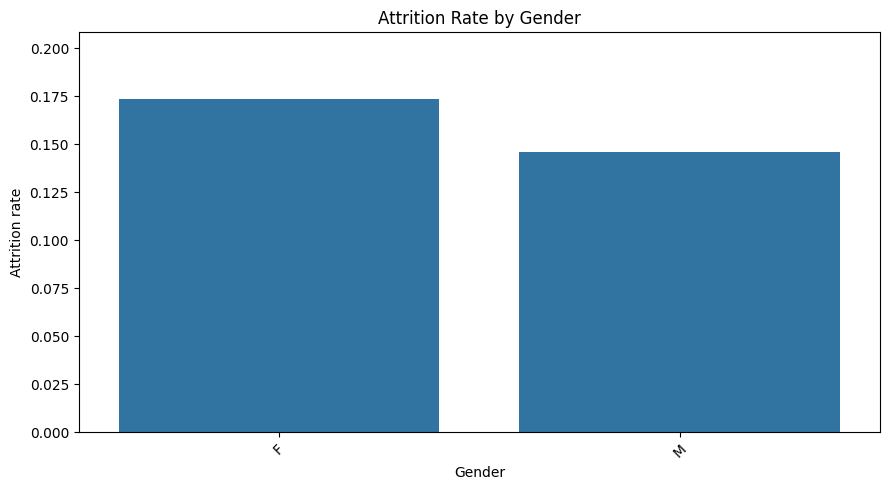

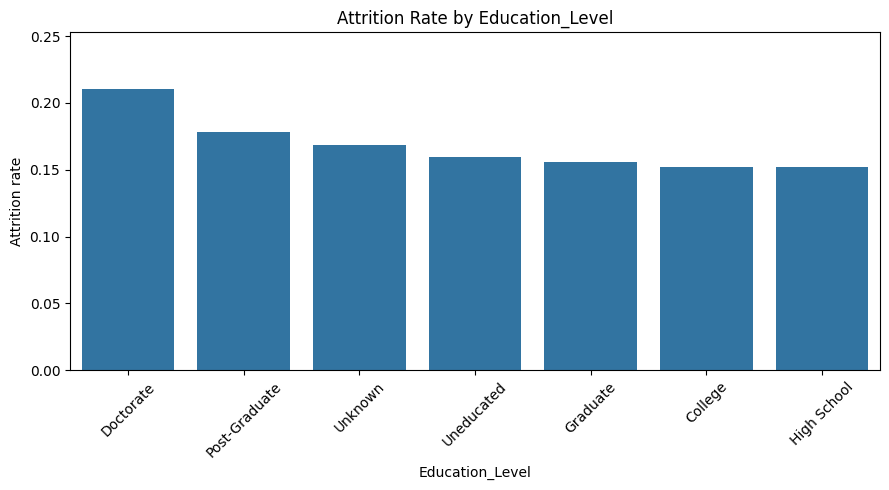

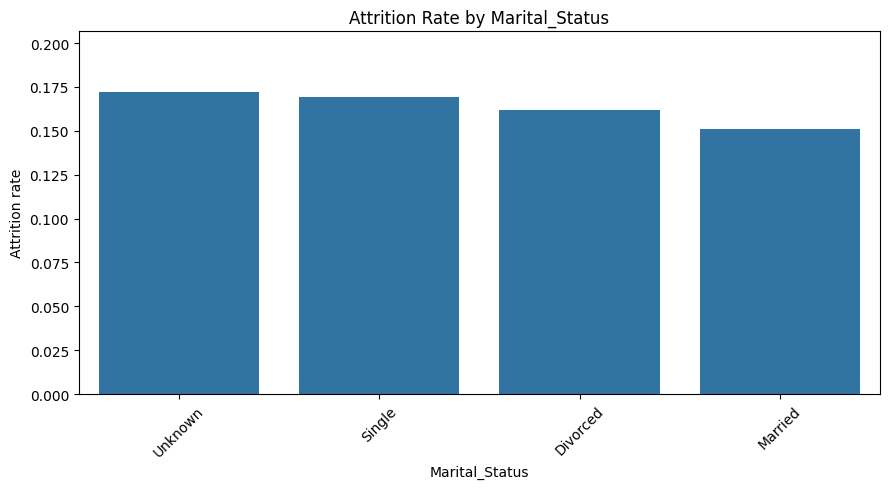

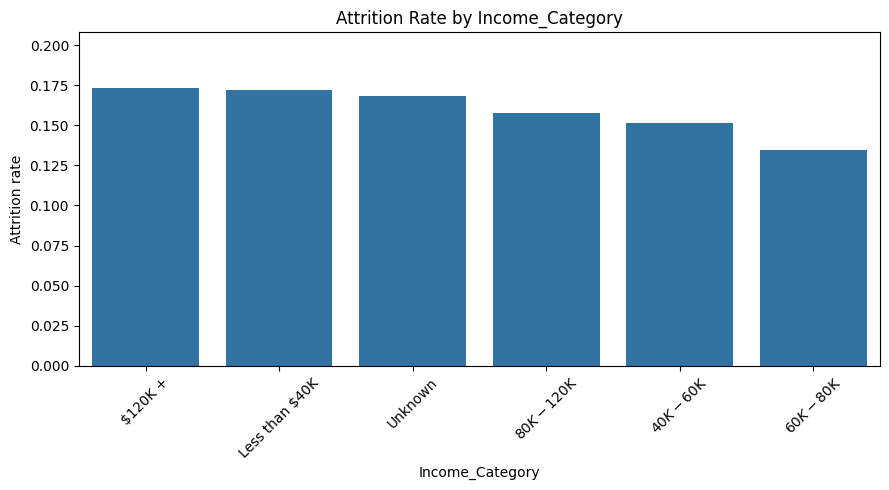

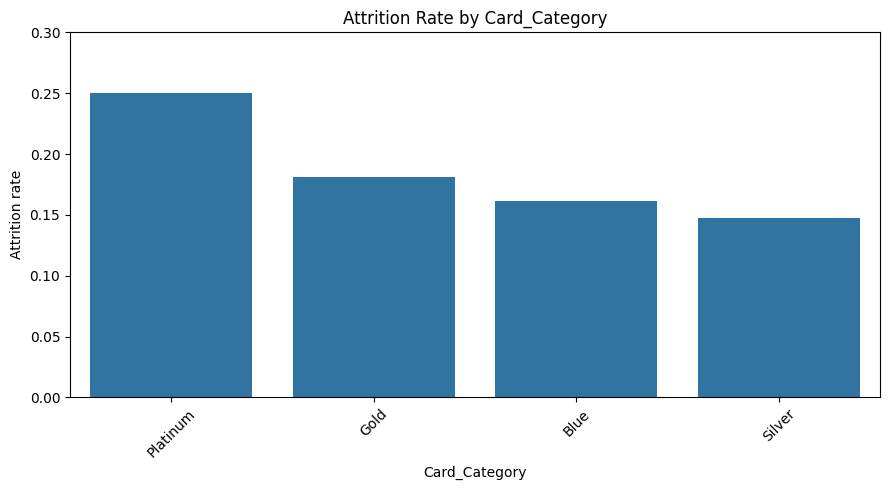

In [13]:
categorical_variables = [
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
]

for variable in categorical_variables:
    
    attrition_rate = (
        df.groupby(variable)['Attrition_Flag']
          .apply(lambda x: (x == 'Attrited Customer').mean())
          .sort_values(ascending=False)
    )
    
    plt.figure(figsize=(9, 5))
    
    sns.barplot(
        x=attrition_rate.index,
        y=attrition_rate.values
    )
    
    plt.title(f'Attrition Rate by {variable}')
    plt.xlabel(variable)
    plt.ylabel('Attrition rate')
    plt.ylim(0, attrition_rate.max() * 1.2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()